<a href="https://colab.research.google.com/github/Marlon-Sbardelatti/machine-learning/blob/feature%2Fseminario/seminario/urban_fire.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Instala dependências
!pip install datasets tensorflow scikit-learn pillow

In [ ]:
from datasets import load_dataset

# Carregar dataset do HuggingFace
dataset = load_dataset(
    path='incrisvel/urban-fire-identification'
)

In [ ]:
# Separar deterministicamente amostras de treino e teste
split_dataset = dataset['train'].train_test_split(
    test_size=0.2,
    stratify_by_column='label',
    seed=1
)

train_data = split_dataset['train']
test_data = split_dataset['test']

# Mostrar estrutura do dataset
split_dataset
split_dataset['train']

Dataset({
    features: ['image', 'label'],
    num_rows: 643
})

In [ ]:
from tensorflow.keras.applications import MobileNetV2, InceptionV3, ResNet50
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess
from tensorflow.keras.applications.inception_v3 import preprocess_input as inception_preprocess
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess

# Carregar CNN pré-treinada
mobilenet = MobileNetV2(
    weights='imagenet',
    include_top=False,
    pooling='avg',
    input_shape=(224, 224, 3)
)

inception = InceptionV3(
    weights='imagenet',
    include_top=False,
    pooling='avg',
    input_shape=(299, 299, 3)
)

resnet = ResNet50(
    weights='imagenet',
    include_top=False,
    pooling='avg',
    input_shape=(224, 224, 3)
)

In [ ]:
CLASS_NAMES = dataset['train'].features['label'].names

# Estruturar dados armazenado para cada modelo
models = {
    'MobileNetV2': {
        'feature_extractor': mobilenet,
        'image_size': (224, 224),
        'preprocess': mobilenet_preprocess
    },
    'InceptionV3': {
        'feature_extractor': inception,
        'image_size': (299, 299),
        'preprocess': inception_preprocess
    },
    'ResNet50': {
        'feature_extractor': resnet,
        'image_size': (224, 224),
        'preprocess': resnet_preprocess
    }
}

In [ ]:
from tensorflow.keras.preprocessing.image import img_to_array
import numpy as np

# Preparar imagens
def preprocess_images(model_name, dataset):
    images = []
    labels = []

    for sample in dataset:
        image = sample['image']

        # Converter para RGB por garantia
        image = image.convert('RGB')

        # Redimensionar imagens para mesmo tamanho
        image = image.resize(models[model_name]['image_size'])

        # Converter imagem para um ndarray
        image = img_to_array(image)

        images.append(image)
        labels.append(sample['label'])

    images = np.array(images)
    labels = np.array(labels)

    # Preprocessamento
    images = models[model_name]['preprocess'](images)

    return images, labels


# Extrair embeddings com CNN pré-treinada
def extract_features(model_name, dataset):

    # Extrair embeddings
    features = models[model_name]['feature_extractor'].predict(
        dataset,
        verbose=0,
        batch_size=32,
    )

    return features

In [ ]:
# Armazenar imagens preprocessadas
for model_name, data in models.items():
    train_images, train_labels = preprocess_images(
        model_name,
        train_data
    )

    test_images, test_labels = preprocess_images(
        model_name,
        test_data
    )

    data['train_images'] = train_images
    data['train_labels'] = train_labels

    data['test_images'] = test_images
    data['test_labels'] = test_labels

In [12]:
import time

# Extrair features do modelo pré-treinado
for model_name, data in models.items():
    start = time.perf_counter()

    X_train = extract_features(
        model_name,
        data['train_images'],
    )

    X_test = extract_features(
        model_name,
        data['test_images']
    )

    end = time.perf_counter()

    data['embeddings'] = {
        'X_train': X_train,
        'X_test': X_test
    }

    # Coletar tempo de extração de features
    data['feature_extraction_time'] = end - start

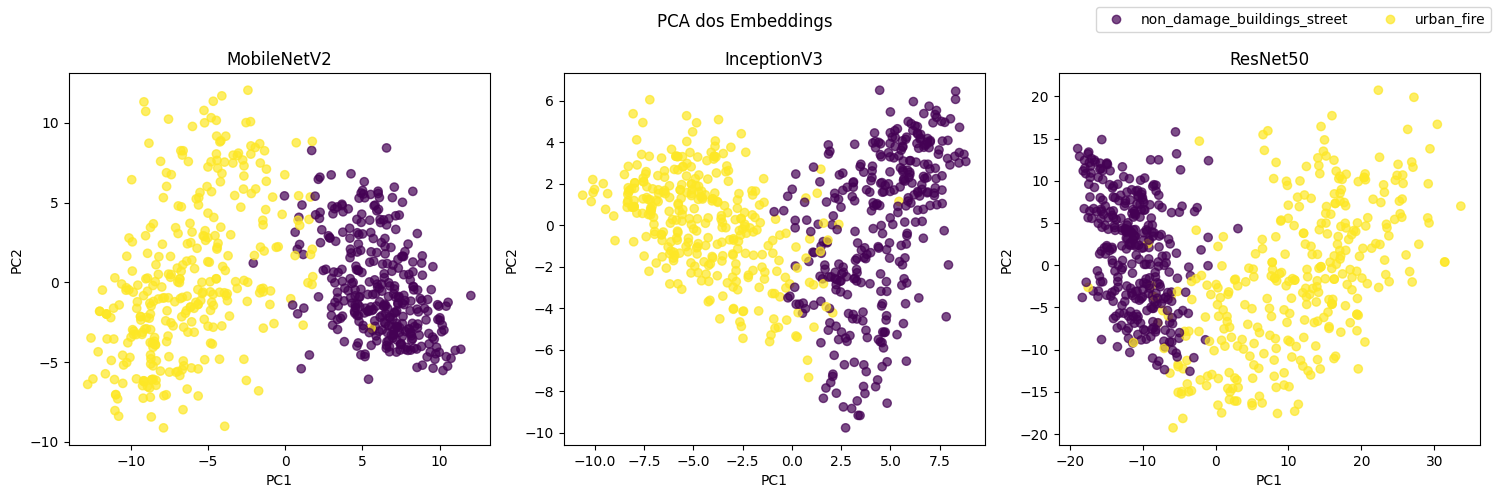

In [13]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

fig, axes = plt.subplots(
    1, 3,
    figsize=(15, 5)
)

# Visualizar os embeddings (Análise de Componentes Principais)
for ax, (model_name, data) in zip(axes, models.items()):

    pca = PCA(n_components=2)

    X_2d = pca.fit_transform(
        data['embeddings']['X_train']
    )

    scatter = ax.scatter(
        X_2d[:, 0],
        X_2d[:, 1],
        c=data['train_labels'],
        alpha=0.7
    )

    ax.set_title(model_name)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')

fig.suptitle('PCA dos Embeddings')

fig.legend(
    handles=scatter.legend_elements()[0],
    labels=CLASS_NAMES,
    ncol=len(CLASS_NAMES)
)

plt.tight_layout()
plt.show()

In [14]:
from sklearn.preprocessing import StandardScaler

# Normalização dos embeddings para SVM
for model_name, data in models.items():
    embeddings = data['embeddings']
    scaler = StandardScaler()
    data['scaler'] = scaler

    X_train_scaled = scaler.fit_transform(embeddings['X_train'])

    X_test_scaled = scaler.transform(embeddings['X_test'])

    embeddings['X_train'] = X_train_scaled
    embeddings['X_test'] = X_test_scaled

In [15]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
    'kernel': ['poly', 'sigmoid', 'rbf']
}

# Encontrar melhores parâmetros para SVM
for model_name, data in models.items():
    embeddings = data['embeddings']
    X_train, y_train = embeddings['X_train'], data['train_labels']

    grid = GridSearchCV(
        SVC(),
        param_grid,
        cv=5,
        scoring='accuracy'
    )

    grid.fit(X_train, y_train)

    data['best_params_svm'] = grid.best_params_

In [16]:
for model_name, data in models.items():
    print(f'Melhores parâmetros para SVM com {model_name}:', data['best_params_svm'])

Melhores parâmetros para SVM com MobileNetV2: {'C': 10, 'kernel': 'sigmoid'}
Melhores parâmetros para SVM com InceptionV3: {'C': 10, 'kernel': 'sigmoid'}
Melhores parâmetros para SVM com ResNet50: {'C': 1, 'kernel': 'sigmoid'}


In [17]:
# Treinar modelo com o melhor SVM
for model_name, data in models.items():
    best_params = data['best_params_svm']
    embeddings = data['embeddings']
    X_train, y_train = embeddings['X_train'], data['train_labels']

    start = time.perf_counter()

    svm = SVC(
        kernel=best_params['kernel'],
        C=best_params['C'],
        gamma='scale'
    )

    svm.fit(X_train, y_train)

    end = time.perf_counter()

    data['model_svm'] = svm
    data['svm_training_time'] = end - start

In [18]:
# Predições dos modelos
for model_name, data in models.items():
    svm = data['model_svm']

    y_pred = svm.predict(data['embeddings']['X_test'])

    data['predictions_svm'] = y_pred

    data['total_svm_time'] = (
        data['feature_extraction_time'] + data['svm_training_time']
    )

============================ MobileNetV2 ============================

Acurácia: 0.98

Relatório da classificação:
                             precision    recall  f1-score   support

non_damage_buildings_street       0.95      1.00      0.98        80
                 urban_fire       1.00      0.95      0.97        81

                   accuracy                           0.98       161
                  macro avg       0.98      0.98      0.98       161
               weighted avg       0.98      0.98      0.98       161


Matriz de confusão:


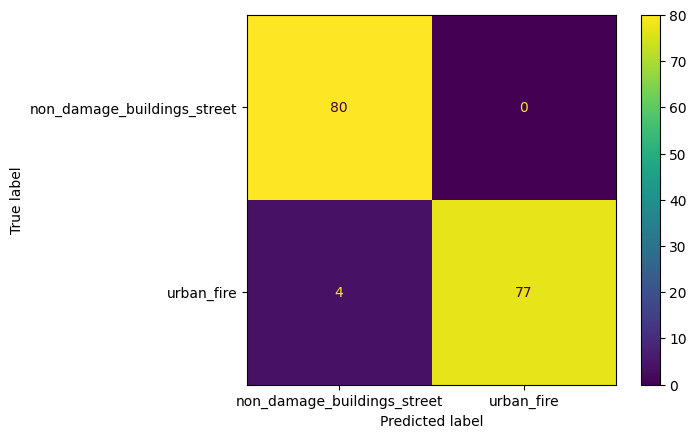

Tempo para extrair embeddings: 42.96s

Tempo de extração + treino: 43.00s

============================ InceptionV3 ============================

Acurácia: 0.98

Relatório da classificação:
                             precision    recall  f1-score   support

non_damage_buildings_street       0.99      0.96      0.97        80
                 urban_fire       0.96      0.99      0.98        81

                   accuracy                           0.98       161
                  macro avg       0.98      0.98      0.98       161
               weighted avg       0.98      0.98      0.98       161


Matriz de confusão:


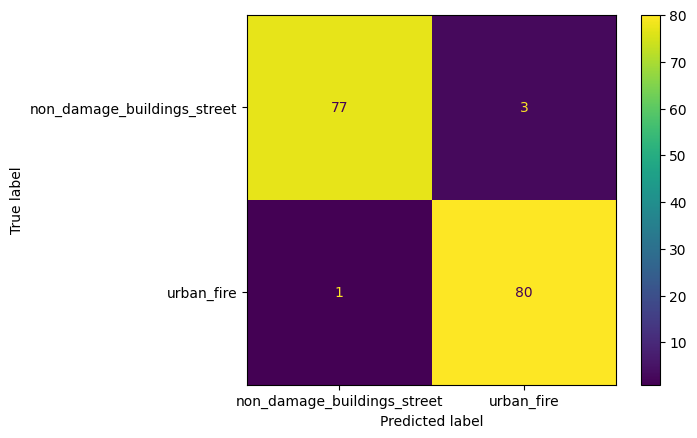

Tempo para extrair embeddings: 160.76s

Tempo de extração + treino: 160.79s

============================ ResNet50 ============================

Acurácia: 1.00

Relatório da classificação:
                             precision    recall  f1-score   support

non_damage_buildings_street       1.00      1.00      1.00        80
                 urban_fire       1.00      1.00      1.00        81

                   accuracy                           1.00       161
                  macro avg       1.00      1.00      1.00       161
               weighted avg       1.00      1.00      1.00       161


Matriz de confusão:


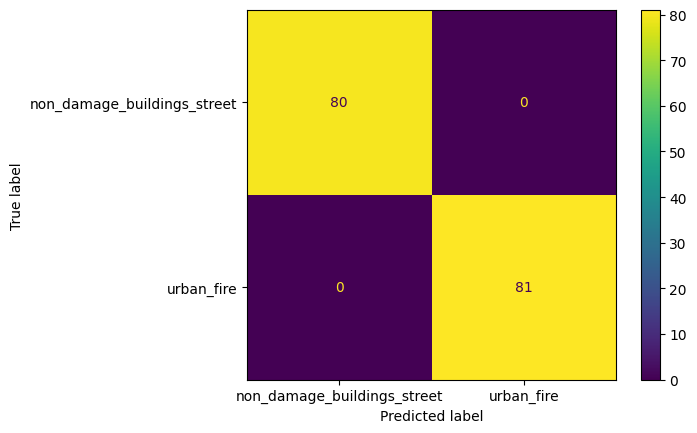

Tempo para extrair embeddings: 103.16s

Tempo de extração + treino: 103.23s



In [19]:
from sklearn.metrics import classification_report, accuracy_score, ConfusionMatrixDisplay

# Métricas de análise (CNN + SVM)
for model_name, data in models.items():
    print(f'{'=' * 28} {model_name} {'=' * 28}')

    y_test = data['test_labels']
    y_pred_svm = data['predictions_svm']

    print(f'\nAcurácia: {accuracy_score(y_test, y_pred_svm):.2f}')

    print('\nRelatório da classificação:')
    print(classification_report(
        y_true=y_test,
        y_pred=y_pred_svm,
        target_names=CLASS_NAMES
    ))

    print(f'\nMatriz de confusão:')
    disp = ConfusionMatrixDisplay.from_predictions(
        y_true=y_test,
        y_pred=y_pred_svm,
        display_labels=CLASS_NAMES
    )

    disp.ax_.grid(False)
    plt.show()

    print(f'Tempo para extrair embeddings: {data['feature_extraction_time']:.2f}s\n')
    print(f'Tempo de extração + treino: {data['total_svm_time']:.2f}s\n')

In [20]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

def create_classifier(feature_extractor):
    # Congelar a CNN pré-treinada
    feature_extractor.trainable = False

    # Adicionar camadas densas
    classifier = Sequential([
        feature_extractor,
        Dense(128, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])

    classifier.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return classifier

In [22]:
from tensorflow.keras.callbacks import EarlyStopping

for model_name, data in models.items():
    start = time.perf_counter()

    # Criar modelo com camadas densas para classificação
    cnn = create_classifier(
        data['feature_extractor']
    )

    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=3,
      restore_best_weights=True
    )

    history = cnn.fit(
        data['train_images'],
        data['train_labels'],
        epochs=20,
        batch_size=32,
        validation_split=0.2,
        callbacks=[early_stop],
        verbose=1
    )

    end = time.perf_counter()

    data['model_cnn'] = cnn
    data['cnn_history'] = history
    data['cnn_training_time'] = end - start

Epoch 1/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.8988 - loss: 0.2249 - val_accuracy: 0.9767 - val_loss: 0.0378
Epoch 2/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - accuracy: 0.9864 - loss: 0.0386 - val_accuracy: 0.9922 - val_loss: 0.0241
Epoch 3/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 16s 948ms/step - accuracy: 0.9961 - loss: 0.0162 - val_accuracy: 0.9922 - val_loss: 0.0268
Epoch 4/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step - accuracy: 0.9981 - loss: 0.0194 - val_accuracy: 0.9922 - val_loss: 0.0270
Epoch 5/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step - accuracy: 0.9981 - loss: 0.0140 - val_accuracy: 0.9922 - val_loss: 0.0186
Epoch 6/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 16s 921ms/step - accuracy: 1.0000 - loss: 0.0059 - val_accuracy: 0.9922 - val_loss: 0.0165
Epoch 7/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 15s 915ms/step - accuracy: 0.9961 - loss: 0.0085 - val_accuracy: 1.0000 - val_loss: 0.0199
Epoch 8/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - accuracy: 1.0000 - loss: 0.0041 - val_accuracy: 0.9922 - 

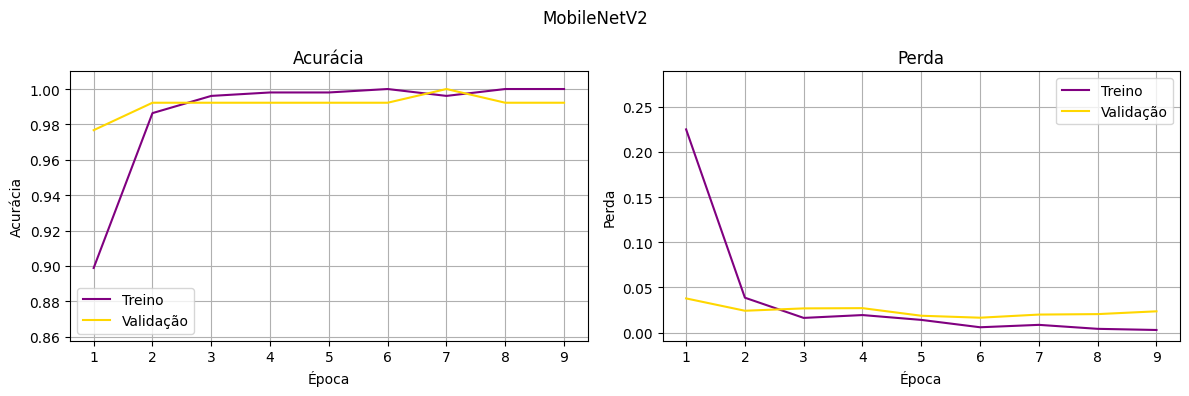

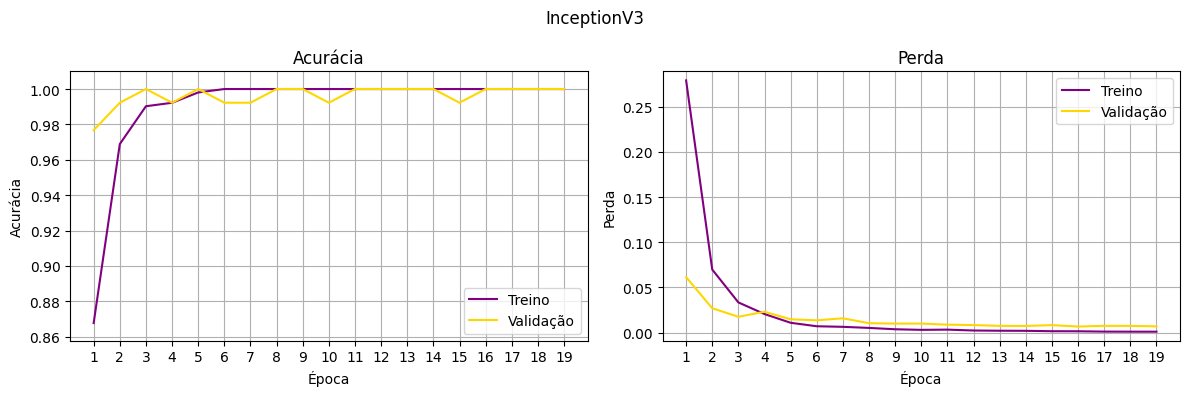

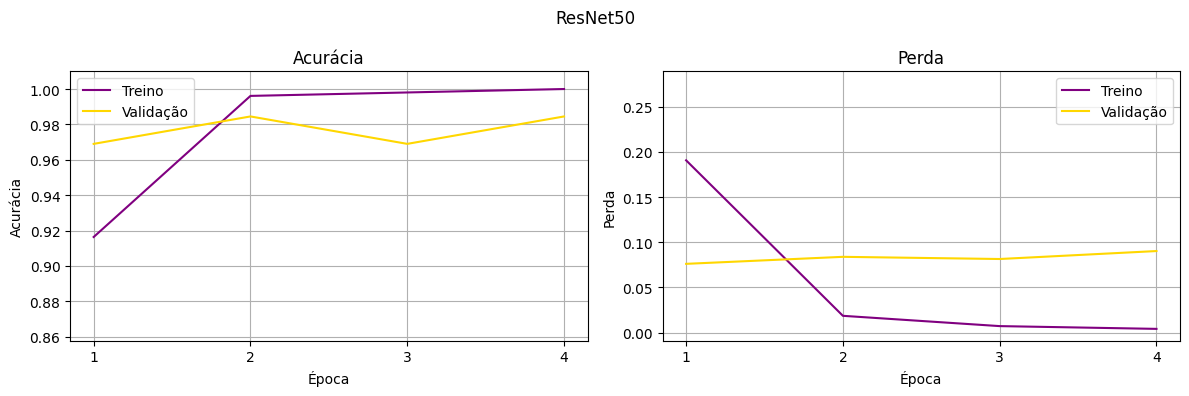

In [27]:
# Encontrar limites globais
all_acc = []
all_loss = []

for data in models.values():

    history = data['cnn_history']

    all_acc.extend(history.history['accuracy'])
    all_acc.extend(history.history['val_accuracy'])

    all_loss.extend(history.history['loss'])
    all_loss.extend(history.history['val_loss'])

acc_limits = (
    min(all_acc) - 0.01,
    max(all_acc) + 0.01
)

loss_limits = (
    min(all_loss) - 0.01,
    max(all_loss) + 0.01
)

# Plotar gráficos dos treinamentos em escala comum
for model_name, data in models.items():
    history = data['cnn_history']

    fig, ax = plt.subplots(
        1, 2,
        figsize=(12, 4)
    )

    fig.suptitle(model_name)

    metrics = [
        ('accuracy', 'Acurácia', acc_limits),
        ('loss', 'Perda', loss_limits)
    ]

    for i, (metric, title, limits) in enumerate(metrics):

        epochs = range(
            1,
            len(history.history['accuracy']) + 1
        )

        ax[i].plot(
            epochs,
            history.history[metric],
            label='Treino',
            color='purple'
        )

        ax[i].plot(
            epochs,
            history.history[f'val_{metric}'],
            label='Validação',
            color='gold'
        )

        ax[i].set_xticks(list(epochs))
        ax[i].set_ylim(*limits)

        ax[i].set_title(title)
        ax[i].set_xlabel('Época')
        ax[i].set_ylabel(title)
        ax[i].legend()
        ax[i].grid(True)

    plt.tight_layout()
    plt.show()

In [ ]:
for model_name, data in models.items():

    y_prob = data['model_cnn'].predict(
        data['test_images'],
        verbose=0
    )

    y_pred = (
        y_prob > 0.5
    ).astype(int).flatten()

    data['predictions_cnn'] = y_pred

============================ MobileNetV2 ============================

Acurácia: 0.99

Relatório da classificação:
                             precision    recall  f1-score   support

non_damage_buildings_street       0.99      1.00      0.99        80
                 urban_fire       1.00      0.99      0.99        81

                   accuracy                           0.99       161
                  macro avg       0.99      0.99      0.99       161
               weighted avg       0.99      0.99      0.99       161


Matriz de confusão:


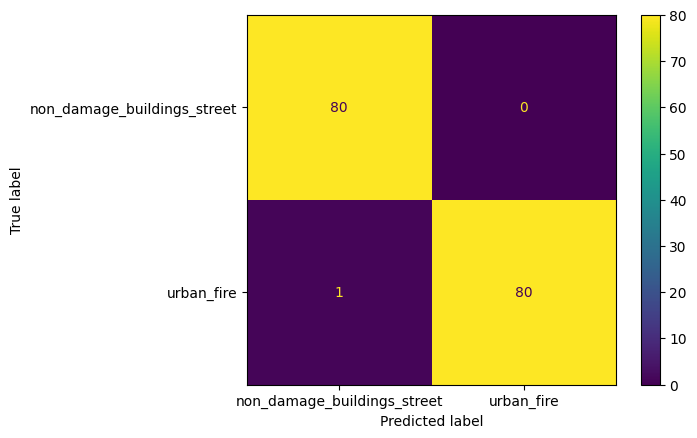

Tempo de treino: 160.21s

============================ InceptionV3 ============================

Acurácia: 0.99

Relatório da classificação:
                             precision    recall  f1-score   support

non_damage_buildings_street       1.00      0.99      0.99        80
                 urban_fire       0.99      1.00      0.99        81

                   accuracy                           0.99       161
                  macro avg       0.99      0.99      0.99       161
               weighted avg       0.99      0.99      0.99       161


Matriz de confusão:


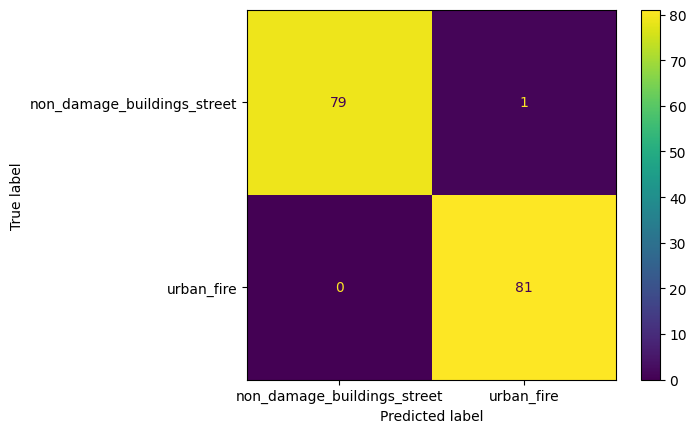

Tempo de treino: 2294.87s

============================ ResNet50 ============================

Acurácia: 0.99

Relatório da classificação:
                             precision    recall  f1-score   support

non_damage_buildings_street       1.00      0.97      0.99        80
                 urban_fire       0.98      1.00      0.99        81

                   accuracy                           0.99       161
                  macro avg       0.99      0.99      0.99       161
               weighted avg       0.99      0.99      0.99       161


Matriz de confusão:


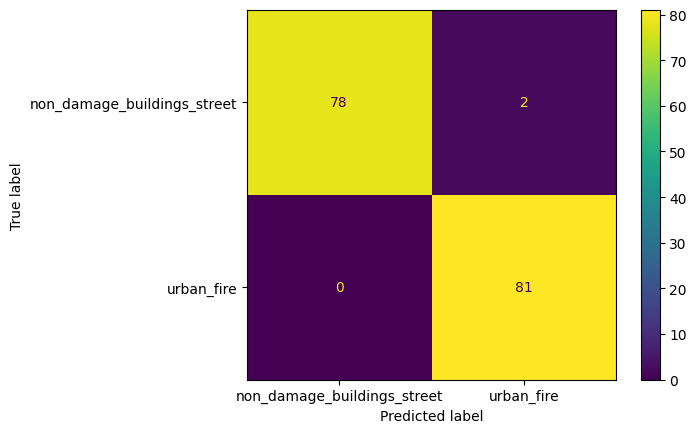

Tempo de treino: 334.17s



In [29]:
# Métricas de análise (CNN com camadas densas)
for model_name, data in models.items():
    print(f'{'=' * 28} {model_name} {'=' * 28}')

    y_test = data['test_labels']
    y_pred_cnn = data['predictions_cnn']

    print(f'\nAcurácia: {accuracy_score(y_test, y_pred_cnn):.2f}')

    print('\nRelatório da classificação:')
    print(classification_report(
        y_true=y_test,
        y_pred=y_pred_cnn,
        target_names=CLASS_NAMES
    ))

    print(f'\nMatriz de confusão:')
    disp = ConfusionMatrixDisplay.from_predictions(
        y_true=y_test,
        y_pred=y_pred_cnn,
        display_labels=CLASS_NAMES
    )
    disp.ax_.grid(False)
    plt.show()

    print(f'Tempo de treino: {data['cnn_training_time']:.2f}s\n')



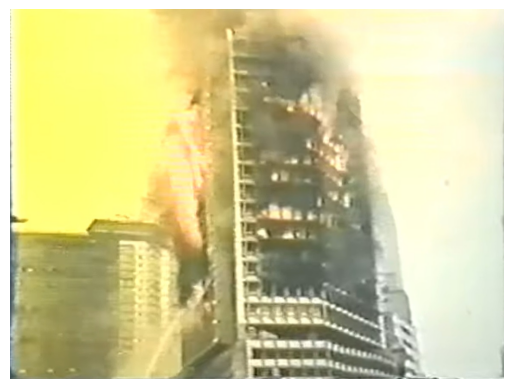

In [25]:
# Análise de uma imagem de teste por todos os modelos
from PIL import Image

image_path = '/content/test.jpg'

img = Image.open(image_path)

plt.imshow(img)
plt.axis("off")
plt.show()

In [28]:
for model_name, data in models.items():

    image = Image.open(image_path).convert("RGB")

    image = image.resize(
        models[model_name]['image_size']
    )

    image = img_to_array(image)

    image = np.expand_dims(image, axis=0)

    image = models[model_name]['preprocess'](image)

    embedding = data['feature_extractor'].predict(
        image,
        verbose=0
    )

    embedding = data['scaler'].transform(
        embedding
    )

    prediction = data['model_svm'].predict(
        embedding
    )[0]

    class_name = CLASS_NAMES[prediction]

    print(f"{model_name} (SVM): {class_name}")

    probability = data['model_cnn'].predict(
        image,
        verbose=0
    )[0][0]

    prediction = int(probability > 0.5)

    class_name = CLASS_NAMES[prediction]

    print(f"{model_name} (CNN): {class_name} - confiança: {probability*100:.2f}%")


MobileNetV2 (SVM): urban_fire
MobileNetV2 (CNN): urban_fire - confiança: 99.22%
InceptionV3 (SVM): urban_fire
InceptionV3 (CNN): urban_fire - confiança: 99.96%
ResNet50 (SVM): urban_fire
ResNet50 (CNN): urban_fire - confiança: 99.99%
